# 中断执行
允许进行交互输入

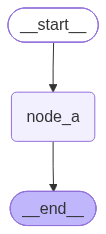

{'__interrupt__': [Interrupt(value='请输入你的姓名', id='5ef2b9537640deaccc791788cf4c55c7')]}


In [1]:
from typing import TypedDict

from IPython.display import display
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langgraph.types import interrupt, Command
from loguru import logger


# 1、声明状态
class OverAllState(TypedDict):
    username: str


# 2、声明节点
def node_a(state: OverAllState) -> OverAllState:
    username = interrupt("请输入你的姓名")
    # 程序执行到中断位置会停下来。等待用户输入后才会执行后续内容
    logger.info("输入的用户姓名：{}", username)
    return {
        "username": username
    }


# 3、构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_edge(START, "node_a")
builder.add_edge("node_a", END)

# 4、想要使用中断，必须配置检查点
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

display(graph)

config = {"configurable": {"thread_id": "123"}}
interrupt_res = graph.invoke({}, config=config)
print(interrupt_res)

In [2]:
prompt = interrupt_res['__interrupt__'][0].value
print(prompt)
username = input(prompt)
# 5、恢复图中的中断执行
# config是必须的，不然图不知道恢复的谁
resume_res = graph.invoke(Command(resume=username), config=config)
print(resume_res)

请输入你的姓名


2026-08-06 09:41:07.289 | INFO     | __main__:node_a:19 - 输入的用户姓名：小义


{'username': '小义'}
